## AutoML Notebook
Tan-Gatue, *Aspiring Data Scientist*

# Curve Fitting

Steps:
- from scipy.optimize import curve_fit
- define the function we want to fit
- the curve_fit() function returns 2 objects
- popt - optimal values for the parameters
- pcov - estimated covariance of popt (not important right now)
- calculate sum of squared residuals (SSR)
- print the calculated optimal values and the SSR up to 6 decimals
- generate an array of size 100 that covers the range of x values in equally spaced increments
- plot your x-range against your function


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import inspect
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from itertools import product
import shutup
shutup.please()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import inspect


def fit_model(model_func, x, y, p0=None, n_points=100, plot=True):
    """
    model_func: function of form f(x, *params)
    x, y: data
    p0: optional initial parameter guess
    n_points: resolution for plotting
    plot: whether to plot fitted curve
    """
    # fit
    if p0 is None:
        popt, pcov = curve_fit(model_func, x, y)
    else:
        popt, pcov = curve_fit(model_func, x, y, p0=p0)

    # predictions
    y_hat = model_func(x, *popt)

    # SSR
    ssr = np.sum((y - y_hat) ** 2)

    # parameter names (skip first arg: x)
    param_names = list(inspect.signature(model_func).parameters.keys())[1:]

    # print parameters
    for name, val in zip(param_names, popt):
        print(f"{name} = {val:.6f}")

    print(f"SSR = {ssr:.6f}")

    # plotting
    if plot:
        x_range = np.linspace(np.min(x), np.max(x), n_points)
        y_range = model_func(x_range, *popt)

        plt.plot(x_range, y_range, 'r')
        plt.scatter(x, y)
        plt.show()

    return {
        "params": dict(zip(param_names, popt)),
        "popt": popt,
        "pcov": pcov,
        "ssr": ssr
    }

In [5]:
# Functional forms
# Linear
def linear(x, m, b):
    return m*x + b


# Quadratic
def quadratic(x, a, b, c):
    return a*x**2 + b*x + c


# Cubic
def cubic(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d


# Frequency (sinusoidal)
def sine(x, A, f, C, D):
    return A * np.sin((2 * np.pi * f * x) + C) + D 

def cos(x, A, f, C, D):
    return A * np.cos((2 * np.pi * f * x) + C) + D 

# Exponential
def exponential(x, a, b, c):
    return a * np.exp(b*x) + c


# Gaussian
def gaussian(x, mean, stdev):
    return (1/np.sqrt(2 * np.pi * stdev**2)) * np.exp(-(x - mean)**2 / (2*stdev**2))


# Power
def power(x, a, b):
    return a * x**b


# Logistic
def logistic(x, A, k, x0):
    return A/(1 + np.exp(-k * (x - x0)))

In [6]:
# COMBO FITTING EXAMPLE

def combo1(x,A,alpha,A2,f,C,D):
    return A*(np.power(x,-alpha)) + A2 * np.sin((2 * np.pi * f * x) + C) + D 

popt, pcov = curve_fit(combo1,x,y)
ssr = sum((y -  combo1(x, *popt))**2)

print(f' SSR = {ssr:.6f}')

x_range = np.linspace(min(x),max(x), 100)

plt.plot(x_range, combo1(x_range, *popt), 'r-')
plt.scatter(x,y)

NameError: name 'x' is not defined

# ML models


## KNN Classifier

In [20]:
def knn_classifier(
    X, y,
    neighbor_range=range(1, 50),
    monte_carlo_iterations=49,
    test_size=0.25,
    validation_size=None,
    random_state=None,
    cv=None
):

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split, KFold
    from sklearn.neighbors import KNeighborsClassifier

    # ----------------------------
    # SINGLE SPLIT (diagnostic plot)
    # ----------------------------
    if validation_size is None:

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        use_validation = False

    else:

        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        val_fraction = validation_size / (1 - test_size)

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val,
            y_train_val,
            test_size=val_fraction,
            random_state=random_state
        )

        use_validation = True

    training_accuracy = []
    test_accuracy = []
    validation_accuracy = []

    for k in neighbor_range:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)

        training_accuracy.append(model.score(X_train, y_train))
        test_accuracy.append(model.score(X_test, y_test))

        if use_validation:
            validation_accuracy.append(model.score(X_val, y_val))

    plt.figure(figsize=(8, 5))
    plt.plot(neighbor_range, training_accuracy, label="training accuracy")
    plt.plot(neighbor_range, test_accuracy, label="test accuracy")

    if use_validation:
        plt.plot(neighbor_range, validation_accuracy, label="validation accuracy")

    plt.xlabel("n_neighbors")
    plt.ylabel("Accuracy")
    plt.title("Single Split KNN Accuracy")
    plt.legend()
    plt.show()

    # ----------------------------
    # CONTAINERS
    # ----------------------------
    cv_train = pd.DataFrame()
    cv_test = pd.DataFrame()
    cv_val = pd.DataFrame()

    # ----------------------------
    # K-FOLD MODE
    # ----------------------------
    if cv is not None:

        kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)

        for fold, (train_idx, test_idx) in enumerate(kf.split(X)):

            X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
            y_train_cv, y_test_cv = y[train_idx], y[test_idx]

            train_scores = []
            test_scores = []

            for k in neighbor_range:
                model = KNeighborsClassifier(n_neighbors=k)
                model.fit(X_train_cv, y_train_cv)

                train_scores.append(model.score(X_train_cv, y_train_cv))
                test_scores.append(model.score(X_test_cv, y_test_cv))

            cv_train[fold] = train_scores
            cv_test[fold] = test_scores

        title = f"{cv}-Fold CV KNN Accuracy"

    # ----------------------------
    # 3-WAY MONTE CARLO
    # ----------------------------
    elif validation_size is not None:

        for seed in range(1, monte_carlo_iterations + 1):

            X_train_val, X_test, y_train_val, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )

            val_fraction = validation_size / (1 - test_size)

            X_train, X_val, y_train, y_val = train_test_split(
                X_train_val,
                y_train_val,
                test_size=val_fraction,
                random_state=seed
            )

            train_scores = []
            test_scores = []
            val_scores = []

            for k in neighbor_range:
                model = KNeighborsClassifier(n_neighbors=k)
                model.fit(X_train, y_train)

                train_scores.append(model.score(X_train, y_train))
                test_scores.append(model.score(X_test, y_test))
                val_scores.append(model.score(X_val, y_val))

            cv_train[seed] = train_scores
            cv_test[seed] = test_scores
            cv_val[seed] = val_scores

        title = "3-Way Split Monte Carlo KNN Accuracy"

    # ----------------------------
    # MONTE CARLO (matches original)
    # ----------------------------
    else:

        for seed in range(1, monte_carlo_iterations + 1):

            X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
                X, y,
                test_size=test_size,
                random_state=seed
            )

            train_scores = []
            test_scores = []

            for k in neighbor_range:
                model = KNeighborsClassifier(n_neighbors=k)
                model.fit(X_train_mc, y_train_mc)

                train_scores.append(model.score(X_train_mc, y_train_mc))
                test_scores.append(model.score(X_test_mc, y_test_mc))

            cv_train[seed] = train_scores
            cv_test[seed] = test_scores

        title = "Monte Carlo KNN Accuracy"

    # ----------------------------
    # FINAL PLOT (same as first code)
    # ----------------------------
    plt.figure(figsize=(8, 5))

    plt.errorbar(
        neighbor_range,
        cv_train.mean(axis=1),
        yerr=cv_train.std(axis=1)/2,
        label="training accuracy"
    )

    plt.errorbar(
        neighbor_range,
        cv_test.mean(axis=1),
        yerr=cv_test.std(axis=1)/6,
        label="test accuracy"
    )

    if not cv_val.empty:
        plt.errorbar(
            neighbor_range,
            cv_val.mean(axis=1),
            yerr=cv_val.std(axis=1)/6,
            label="validation accuracy"
        )

    plt.xlabel("n_neighbors")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

    return cv_train, cv_test, cv_val

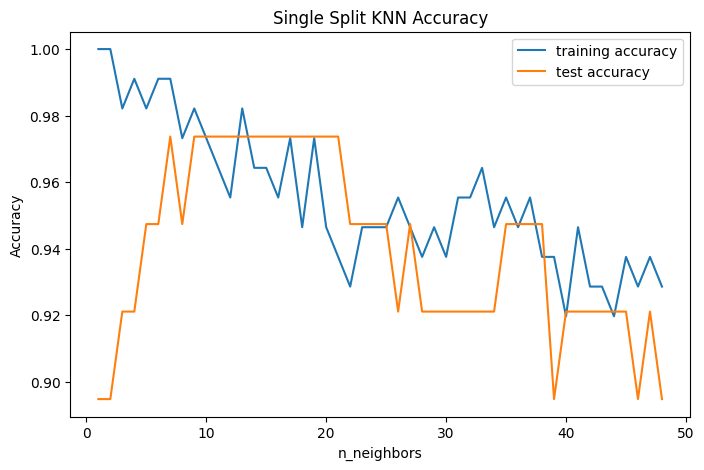

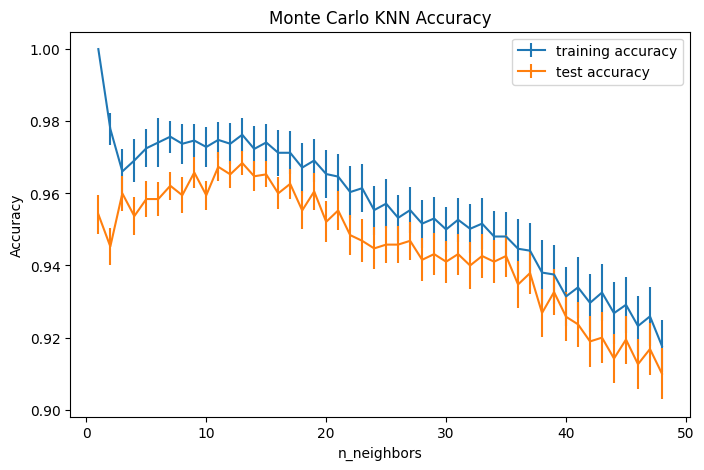

(          1         2         3         4         5         6         7   \
 0   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
 1   0.973214  0.964286  0.973214  0.982143  0.982143  0.982143  0.991071   
 2   0.946429  0.946429  0.964286  0.973214  0.973214  0.973214  0.973214   
 3   0.955357  0.955357  0.964286  0.973214  0.973214  0.973214  0.973214   
 4   0.955357  0.955357  0.973214  0.973214  0.982143  0.982143  0.982143   
 5   0.955357  0.946429  0.982143  0.991071  0.982143  0.964286  0.991071   
 6   0.964286  0.964286  0.982143  0.982143  0.982143  0.964286  0.991071   
 7   0.973214  0.964286  0.973214  0.991071  0.973214  0.964286  0.982143   
 8   0.973214  0.973214  0.973214  0.982143  0.982143  0.964286  0.991071   
 9   0.973214  0.973214  0.973214  0.991071  0.982143  0.964286  0.991071   
 10  0.973214  0.982143  0.973214  0.982143  0.982143  0.964286  0.991071   
 11  0.973214  0.982143  0.973214  0.982143  0.982143  0.964286  0.991071   

In [21]:
from sklearn.datasets import load_iris
ds = load_iris()
X = pd.DataFrame(ds['data'], columns=ds['feature_names'])
y = ds['target']

knn_classifier(X, y, neighbor_range=range(1, 49), monte_carlo_iterations=50,random_state = 20)
#knn_classifier(X,y,cv=5)

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.neighbors import KNeighborsRegressor


def knn_regressor(
    X,
    y,
    test_size=0.25,
    n_neighbors_range=range(1, 15),
    monte_carlo_iterations=49,
    validation_size=None,  # NEW: for 3-way split
    cv=None,               # NEW: number of folds
    plot_results=True
):
    """
    KNN regression supporting pseudo Monte Carlo, 3-way split, or K-Fold CV.
    """

    cv_train = pd.DataFrame()
    cv_test = pd.DataFrame()
    cv_val = pd.DataFrame()  # validation scores

    # ----------------------------
    # SINGLE SPLIT (baseline curve)
    # ----------------------------
    if validation_size is None:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
        use_validation = False
    else:
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
        val_fraction = validation_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_fraction, random_state=42
        )
        use_validation = True
        print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

    # Single split accuracy curve
    train_scores = []
    test_scores = []
    val_scores = []

    for n in n_neighbors_range:
        reg = KNeighborsRegressor(n_neighbors=n)
        reg.fit(X_train, y_train)

        train_scores.append(reg.score(X_train, y_train))
        test_scores.append(reg.score(X_test, y_test))
        if use_validation:
            val_scores.append(reg.score(X_val, y_val))

    plt.figure(figsize=(12, 5))
    plt.plot(n_neighbors_range, train_scores, label="Training $R^2$")
    plt.plot(n_neighbors_range, test_scores, label="Test $R^2$")
    if use_validation:
        plt.plot(n_neighbors_range, val_scores, label="Validation $R^2$")
    plt.xlabel("n_neighbors")
    plt.ylabel("Accuracy ($R^2$)")
    plt.title("KNN Regression Accuracy vs. n_neighbors (Single Split)")
    plt.legend()
    plt.show()

    # ----------------------------
    # K-FOLD CROSS VALIDATION
    # ----------------------------
    if cv is not None:
        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
            X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
            y_train_cv, y_test_cv = y[train_idx], y[test_idx]

            train_fold = []
            test_fold = []

            for n in n_neighbors_range:
                reg = KNeighborsRegressor(n_neighbors=n)
                reg.fit(X_train_cv, y_train_cv)
                train_fold.append(reg.score(X_train_cv, y_train_cv))
                test_fold.append(reg.score(X_test_cv, y_test_cv))

            cv_train[fold] = train_fold
            cv_test[fold] = test_fold

        title = f"{cv}-Fold CV KNN Regression Accuracy"

    # ----------------------------
    # 3-WAY SPLIT MONTE CARLO
    # ----------------------------
    elif validation_size is not None:
        for seed in range(1, monte_carlo_iterations + 1):
            X_train_val, X_test, y_train_val, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )
            val_fraction = validation_size / (1 - test_size)
            X_train, X_val, y_train, y_val = train_test_split(
                X_train_val, y_train_val, test_size=val_fraction, random_state=seed
            )

            train_fold = []
            test_fold = []
            val_fold = []

            for n in n_neighbors_range:
                reg = KNeighborsRegressor(n_neighbors=n)
                reg.fit(X_train, y_train)
                train_fold.append(reg.score(X_train, y_train))
                test_fold.append(reg.score(X_test, y_test))
                val_fold.append(reg.score(X_val, y_val))

            cv_train[seed] = train_fold
            cv_test[seed] = test_fold
            cv_val[seed] = val_fold

        title = "3-Way Split Monte Carlo KNN Regression Accuracy"

    # ----------------------------
    # PSEUDO MONTE CARLO (default)
    # ----------------------------
    else:
        for seed in range(1, monte_carlo_iterations + 1):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )

            train_fold = []
            test_fold = []

            for n in n_neighbors_range:
                reg = KNeighborsRegressor(n_neighbors=n)
                reg.fit(X_train, y_train)
                train_fold.append(reg.score(X_train, y_train))
                test_fold.append(reg.score(X_test, y_test))

            cv_train[seed] = train_fold
            cv_test[seed] = test_fold

        title = "Monte Carlo KNN Regression Accuracy"

    # ----------------------------
    # PLOT MEAN + ERROR
    # ----------------------------
    plt.figure(figsize=(12, 5))
    plt.errorbar(n_neighbors_range, cv_train.mean(axis=1), yerr=cv_train.std(axis=1), label="Training $R^2$")
    plt.errorbar(n_neighbors_range, cv_test.mean(axis=1), yerr=cv_test.std(axis=1), label="Test $R^2$")
    if not cv_val.empty:
        plt.errorbar(n_neighbors_range, cv_val.mean(axis=1), yerr=cv_val.std(axis=1), label="Validation $R^2$")
    plt.xlabel("n_neighbors")
    plt.ylabel("Accuracy ($R^2$)")
    plt.title(title)
    plt.legend()
    plt.show()

    return cv_train, cv_test, cv_val

In [17]:
df = pd.read_csv('Boston.csv')
X= df.drop('nox', axis=1)
y=df['nox']
all_train, all_test = knn_regressor(X, y, n_neighbors_range=range(1, 30))

FileNotFoundError: [Errno 2] No such file or directory: 'Boston.csv'

## OLS Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression

def ols_reg(
    X,
    y,
    df_features=None,
    seeds=100,
    test_size=0.25,
    validation_size=None,  # for 3-way split
    cv=None,               # for K-Fold CV
    plot_coefficients=True
):
    """
    Linear Regression evaluation supporting pseudo Monte Carlo, 3-way split, and K-Fold CV.
    Includes normalized feature importance plots.

    Returns:
        training_scores: DataFrame of training R² per split
        test_scores: DataFrame of test R² per split
        val_scores: DataFrame of validation R² (empty if not used)
        coef_df: DataFrame of coefficients per split
        last_model: last fitted LinearRegression object
    """

    training_scores = pd.DataFrame()
    test_scores = pd.DataFrame()
    val_scores = pd.DataFrame()
    coef_df = pd.DataFrame()

    # Ensure df_features matches number of columns in X
    if df_features is not None:
        if hasattr(df_features, "columns"):
            df_features = df_features.iloc[:, :X.shape[1]]
        else:
            df_features = df_features[:X.shape[1]]

    # ----------------------------
    # Determine split mode
    # ----------------------------
    if cv is not None:
        # K-Fold CV mode
        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx] if isinstance(X, pd.DataFrame) else X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            lr = LinearRegression().fit(X_train, y_train)
            training_scores[fold] = [lr.score(X_train, y_train)]
            test_scores[fold] = [lr.score(X_test, y_test)]
            coef_df[fold] = lr.coef_

        title = f"{cv}-Fold CV Linear Regression"

    elif validation_size is not None:
        # 3-way split Monte Carlo
        if isinstance(seeds, int):
            seeds = range(1, seeds + 1)
        for seed in seeds:
            X_train_val, X_test, y_train_val, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )
            val_fraction = validation_size / (1 - test_size)
            X_train, X_val, y_train, y_val = train_test_split(
                X_train_val, y_train_val, test_size=val_fraction, random_state=seed
            )

            lr = LinearRegression().fit(X_train, y_train)
            training_scores[seed] = [lr.score(X_train, y_train)]
            test_scores[seed] = [lr.score(X_test, y_test)]
            val_scores[seed] = [lr.score(X_val, y_val)]
            coef_df[seed] = lr.coef_

        title = "3-Way Split Monte Carlo Linear Regression"

    else:
        # Pseudo Monte Carlo (default)
        if isinstance(seeds, int):
            seeds = range(1, seeds + 1)
        for seed in seeds:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )

            lr = LinearRegression().fit(X_train, y_train)
            training_scores[seed] = [lr.score(X_train, y_train)]
            test_scores[seed] = [lr.score(X_test, y_test)]
            coef_df[seed] = lr.coef_

        title = "Pseudo Monte Carlo Linear Regression"

    # ----------------------------
    # Print summary
    # ----------------------------
    print("TRAIN SET: Mean = %.4f, Std = %.4f" % (training_scores.mean(axis=1).mean(), training_scores.std(axis=1).mean()))
    print("TEST SET:  Mean = %.4f, Std = %.4f" % (test_scores.mean(axis=1).mean(), test_scores.std(axis=1).mean()))
    if not val_scores.empty:
        print("VAL SET:   Mean = %.4f, Std = %.4f" % (val_scores.mean(axis=1).mean(), val_scores.std(axis=1).mean()))

    # ----------------------------
    # Plot coefficient magnitudes
    # ----------------------------
    if plot_coefficients:
        plt.figure(figsize=(15, 6))
        coef_mean = coef_df.mean(axis=1)
        coef_std = coef_df.std(axis=1)
        plt.errorbar(range(coef_mean.shape[0]), coef_mean, yerr=coef_std, fmt='-v', color='blue', label="Coefficients")
        if df_features is not None:
            plt.xticks(range(df_features.shape[1]), df_features.columns, rotation=90)
        plt.hlines(0, 0, coef_mean.shape[0]-1, color='orange')
        plt.xlabel("Feature")
        plt.ylabel("Coefficient magnitude")
        plt.title(title)
        plt.legend()
        plt.show()
        
        top_idx = np.argmax(np.abs(coef_mean))
        print("Top Predictor = %s, Coefficient = %.4f" % (
            df_features.columns[top_idx] if df_features is not None else top_idx,
            coef_mean[top_idx]
        ))

        # ----------------------------
        # Normalized feature importance
        # ----------------------------
        if df_features is not None:
            weights_normalized = lr.coef_.T / np.sum(np.abs(lr.coef_.T))
            n_features = len(weights_normalized)

            plt.figure(figsize=(10, 6))
            plt.barh(range(n_features), weights_normalized, align='center', color='skyblue')
            plt.yticks(np.arange(n_features), df_features.columns)
            plt.xlabel("Normalized Feature Importance")
            plt.ylabel("Feature")
            plt.ylim(-1, n_features)
            plt.title(f"Normalized Feature Importance ({title})")
            plt.show()

    return training_scores, test_scores, val_scores, coef_df, lr

In [ ]:
# Load your data into a DataFrame
df = pd.read_csv("Boston.csv")  # adjust path
X = df.drop(columns='medv').values
y = df['medv'].values

# Call the function
ols_reg(X, y, df_features=df, seeds=100, test_size=0.25, plot_coefficients=True)

## Ridge Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold

def regression_evaluation(
    X,
    y,
    model_class,
    model_params=None,
    df_features=None,
    seeds=100,
    test_size=0.25,
    validation_size=None,  # for 3-way split
    cv=None,               # number of folds for K-Fold CV
    plot_coefficients=True
):
    """
    Evaluate a regression model using pseudo Monte Carlo, 3-way split, or K-Fold CV.
    Includes normalized feature importance plots.
    """

    if model_params is None:
        model_params = {}

    training_scores = pd.DataFrame()
    test_scores = pd.DataFrame()
    val_scores = pd.DataFrame()
    coef_df = pd.DataFrame()

    # Ensure df_features matches number of columns in X
    if df_features is not None:
        if hasattr(df_features, "columns"):
            df_features = df_features.iloc[:, :X.shape[1]]
        else:
            df_features = df_features[:X.shape[1]]

    # ----------------------------
    # K-Fold Cross-Validation
    # ----------------------------
    if cv is not None:
        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
            X_train, X_test = (X.iloc[train_idx], X.iloc[test_idx]) if isinstance(X, pd.DataFrame) else (X[train_idx], X[test_idx])
            y_train, y_test = y[train_idx], y[test_idx]

            model = model_class(**model_params).fit(X_train, y_train)
            training_scores[fold] = [model.score(X_train, y_train)]
            test_scores[fold] = [model.score(X_test, y_test)]
            coef_df[fold] = model.coef_
        title = f"{cv}-Fold CV Regression"

    # ----------------------------
    # 3-Way Split Monte Carlo
    # ----------------------------
    elif validation_size is not None:
        if isinstance(seeds, int):
            seeds = range(1, seeds + 1)
        for seed in seeds:
            X_train_val, X_test, y_train_val, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )
            val_fraction = validation_size / (1 - test_size)
            X_train, X_val, y_train, y_val = train_test_split(
                X_train_val, y_train_val, test_size=val_fraction, random_state=seed
            )

            model = model_class(**model_params).fit(X_train, y_train)
            training_scores[seed] = [model.score(X_train, y_train)]
            test_scores[seed] = [model.score(X_test, y_test)]
            val_scores[seed] = [model.score(X_val, y_val)]
            coef_df[seed] = model.coef_
        title = "3-Way Split Monte Carlo Regression"

    # ----------------------------
    # Pseudo Monte Carlo (Repeated Holdout)
    # ----------------------------
    else:
        if isinstance(seeds, int):
            seeds = range(1, seeds + 1)
        for seed in seeds:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )
            model = model_class(**model_params).fit(X_train, y_train)
            training_scores[seed] = [model.score(X_train, y_train)]
            test_scores[seed] = [model.score(X_test, y_test)]
            coef_df[seed] = model.coef_
        title = "Pseudo Monte Carlo Regression"

    # ----------------------------
    # Summary Statistics
    # ----------------------------
    print("TRAIN SET: Mean = %.4f, Std = %.4f" % (training_scores.mean(axis=1).mean(), training_scores.std(axis=1).mean()))
    print("TEST SET:  Mean = %.4f, Std = %.4f" % (test_scores.mean(axis=1).mean(), test_scores.std(axis=1).mean()))
    if not val_scores.empty:
        print("VAL SET:   Mean = %.4f, Std = %.4f" % (val_scores.mean(axis=1).mean(), val_scores.std(axis=1).mean()))

    # ----------------------------
    # Plot coefficient magnitudes
    # ----------------------------
    if plot_coefficients:
        plt.figure(figsize=(15, 6))
        coef_mean = coef_df.mean(axis=1)
        coef_std = coef_df.std(axis=1)
        plt.errorbar(range(coef_mean.shape[0]), coef_mean, yerr=coef_std, fmt='-v', color='blue', label='Coefficients')
        plt.hlines(0, 0, coef_mean.shape[0]-1, color='orange')
        if df_features is not None:
            plt.xticks(range(df_features.shape[1]), df_features.columns if hasattr(df_features, "columns") else df_features, rotation=90)
        plt.xlabel("Feature")
        plt.ylabel("Coefficient magnitude")
        plt.title(title)
        plt.legend()
        plt.show()

        top_idx = np.argmax(np.abs(coef_mean))
        print("Top predictor coefficient = %.4f" % coef_mean[top_idx])
        if df_features is not None:
            feature_name = (df_features.columns[top_idx] if hasattr(df_features, "columns") else df_features[top_idx])
            print("Top predictor = %s" % feature_name)

        # ----------------------------
        # Normalized feature importance
        # ----------------------------
        if df_features is not None:
            weights_normalized = model.coef_.T / np.sum(np.abs(model.coef_.T))
            n_features = len(weights_normalized)
            plt.figure(figsize=(10, 6))
            plt.barh(range(n_features), weights_normalized, align='center', color='skyblue')
            plt.yticks(np.arange(n_features), df_features.columns if hasattr(df_features, "columns") else df_features)
            plt.xlabel("Normalized Feature Importance")
            plt.ylabel("Feature")
            plt.ylim(-1, n_features)
            plt.title(f"Normalized Feature Importance ({title})")
            plt.show()

    return training_scores, test_scores, val_scores, coef_df, model

In [ ]:
from sklearn.linear_model import Ridge, LinearRegression

# Example 1: Ridge regression
training_scores, test_scores, val_scores, coef_df, model = regression_evaluation(
    X, y,
    model_class=Ridge,
    model_params={'alpha': 0.4},
    df_features=df,  # or a list of names
    seeds=100,
    test_size=0.25)
ridge_model

## Lasso Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Lasso

def lasso_evaluation(
    X,
    y,
    alphas=[1.0, 0.1, 0.01],
    df_features=None,
    seeds=50,
    test_size=0.25,
    validation_size=None,  # for 3-way split
    cv=None,               # number of folds for K-Fold CV
    plot_coefficients=True
):
    """
    Lasso regression evaluation with pseudo Monte Carlo, 3-way split, or K-Fold CV.
    Includes normalized feature importance plots.
    """

    if isinstance(seeds, int):
        seeds = range(1, seeds+1)

    # Ensure df_features matches X columns
    if df_features is not None:
        if hasattr(df_features, "columns"):
            df_features = df_features.iloc[:, :X.shape[1]]
        else:
            df_features = df_features[:X.shape[1]]

    results = {}

    for alpha in alphas:
        training_scores = pd.DataFrame()
        test_scores = pd.DataFrame()
        val_scores = pd.DataFrame()
        coef_df = pd.DataFrame()
        last_model = None

        # ----------------------------
        # K-Fold CV
        # ----------------------------
        if cv is not None:
            kf = KFold(n_splits=cv, shuffle=True, random_state=42)
            for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
                X_train, X_test = (X.iloc[train_idx], X.iloc[test_idx]) if isinstance(X, pd.DataFrame) else (X[train_idx], X[test_idx])
                y_train, y_test = y[train_idx], y[test_idx]

                model = Lasso(alpha=alpha, max_iter=10000).fit(X_train, y_train)
                training_scores[fold] = [model.score(X_train, y_train)]
                test_scores[fold] = [model.score(X_test, y_test)]
                coef_df[fold] = model.coef_
                last_model = model

        # ----------------------------
        # 3-Way Split Monte Carlo
        # ----------------------------
        elif validation_size is not None:
            for seed in seeds:
                X_train_val, X_test, y_train_val, y_test = train_test_split(
                    X, y, test_size=test_size, random_state=seed
                )
                val_fraction = validation_size / (1 - test_size)
                X_train, X_val, y_train, y_val = train_test_split(
                    X_train_val, y_train_val, test_size=val_fraction, random_state=seed
                )

                model = Lasso(alpha=alpha, max_iter=10000).fit(X_train, y_train)
                training_scores[seed] = [model.score(X_train, y_train)]
                test_scores[seed] = [model.score(X_test, y_test)]
                val_scores[seed] = [model.score(X_val, y_val)]
                coef_df[seed] = model.coef_
                last_model = model

        # ----------------------------
        # Pseudo Monte Carlo (Repeated Holdout)
        # ----------------------------
        else:
            for seed in seeds:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=test_size, random_state=seed
                )
                model = Lasso(alpha=alpha, max_iter=10000).fit(X_train, y_train)
                training_scores[seed] = [model.score(X_train, y_train)]
                test_scores[seed] = [model.score(X_test, y_test)]
                coef_df[seed] = model.coef_
                last_model = model

        # ----------------------------
        # Summary
        # ----------------------------
        print(f"ALPHA = {alpha}")
        print("TRAIN SET: Mean = %.4f, Std = %.4f" % (training_scores.mean(axis=1).mean(), training_scores.std(axis=1).mean()))
        print("TEST SET:  Mean = %.4f, Std = %.4f" % (test_scores.mean(axis=1).mean(), test_scores.std(axis=1).mean()))
        if not val_scores.empty:
            print("VAL SET:   Mean = %.4f, Std = %.4f" % (val_scores.mean(axis=1).mean(), val_scores.std(axis=1).mean()))
        print("Number of features used:", np.sum(last_model.coef_ != 0))
        print("-"*50)

        results[alpha] = {
            "training_scores": training_scores,
            "test_scores": test_scores,
            "val_scores": val_scores,
            "coef_df": coef_df,
            "model": last_model,
            "n_features_used": np.sum(last_model.coef_ != 0)
        }

    # ----------------------------
    # Plot coefficient magnitudes
    # ----------------------------
    if plot_coefficients:
        plt.figure(figsize=(15, 8))
        for alpha in alphas:
            coef_mean = results[alpha]["coef_df"].mean(axis=1)
            coef_std = results[alpha]["coef_df"].std(axis=1)
            plt.errorbar(range(coef_mean.shape[0]), coef_mean, yerr=coef_std, fmt='o-', label=f"Lasso alpha={alpha}")
        plt.xlabel("Feature")
        plt.ylabel("Coefficient magnitude")
        if df_features is not None:
            plt.xticks(range(df_features.shape[1]), df_features.columns if hasattr(df_features, "columns") else df_features, rotation=90)
        plt.legend()
        plt.show()

        # ----------------------------
        # Normalized feature importance
        # ----------------------------
        if df_features is not None:
            plt.figure(figsize=(10, 6))
            for alpha in alphas:
                coef_mean = results[alpha]["coef_df"].mean(axis=1)
                weights_normalized = coef_mean.T / np.sum(np.abs(coef_mean.T))
                n_features = len(weights_normalized)
                plt.barh(np.arange(n_features), weights_normalized, alpha=0.6, label=f"alpha={alpha}")
            plt.yticks(np.arange(n_features), df_features.columns if hasattr(df_features, "columns") else df_features)
            plt.xlabel("Normalized Feature Importance")
            plt.ylabel("Feature")
            plt.ylim(-1, n_features)
            plt.title("Normalized Feature Importance (Lasso)")
            plt.legend()
            plt.show()

    return results

In [ ]:
# Assuming df is a pandas DataFrame with target column 'medv'
X = df.drop(columns='medv').values
y = df['medv'].values

results = lasso_evaluation(X, y, alphas=[1.0], df_features=df, seeds=200)

## SVM/Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def svm_logistic(X, y, model_type='logistic', C=1.0, test_size=0.25, random_state=42, scale_data=True):
    """
    General function for training and evaluating linear classifiers.

    Parameters:
    - X, y: Features and target labels.
    - model_type: 'logistic' for Logistic Regression or 'svm' for Linear SVC.
    - C: Regularization parameter (inverse of strength).
    - test_size: Fraction of data for testing.
    - random_state: Seed for reproducibility.
    - scale_data: Whether to standardize features (recommended for SVM).
    
    Returns:
    - Dictionary containing the trained model, confusion matrix, true labels, and predictions.
    """
    
    # 1. Data Splitting
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # 2. Feature Scaling (optional)
    if scale_data:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    # 3. Model Initialization
    if model_type == 'logistic':
        clf = LogisticRegression(C=C, max_iter=1000, solver='lbfgs')
    elif model_type == 'svm':
        clf = LinearSVC(C=C, max_iter=10000)
    else:
        raise ValueError("model_type must be 'logistic' or 'svm'")
    
    # 4. Model Training
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # 5. Text Evaluation
    print(f"--- Model: {model_type.upper()} (C={C}) ---")
    print(classification_report(y_test, y_pred))
    
    # 6. Confusion Matrix Visualization
    confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
    fig, ax = plt.subplots(figsize=(max(4, confmat.shape[1]), max(4, confmat.shape[0])))
    cax = ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.7)
    plt.colorbar(cax)
    
    for i in range(confmat.shape[0]):
        for j in range(confmat.shape[1]):
            ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')
    
    plt.title(f'Confusion Matrix: {model_type.upper()}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()
    
    # 7. Return structured output
    return {'model': clf, 'confusion_matrix': confmat, 'y_test': y_test, 'y_pred': y_pred}

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# 1. Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Run the AutoML function
# We will use Logistic Regression with a regularization strength of C=1.0
model = svm_logistic(
    X, 
    y, 
    model_type='logistic', 
    C=.5, 
    test_size=0.3, 
    random_state=42
)

# The function will output:
# - A classification report (Precision, Recall, F1-score)
# - A graphical Confusion Matrix

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import numpy as np

def find_best_C(X, y, C_values=None, cv_folds=5, random_state=42):
    """
    Finds the best C for a Linear SVM using cross-validation.

    Parameters:
    - X, y: Features and labels (scaled is recommended)
    - C_values: List or array of C values to test. Default: logarithmic scale from 0.01 to 100.
    - cv_folds: Number of cross-validation folds
    - random_state: For reproducibility

    Returns:
    - best_C: C value with highest mean cross-validation score
    - cv_scores: Dictionary of C vs mean CV score
    """
    if C_values is None:
        C_values = np.logspace(-2, 2, 10)  # 0.01 → 100

    cv_scores = {}
    for C in C_values:
        clf = LinearSVC(C=C, max_iter=10000, random_state=random_state)
        scores = cross_val_score(clf, X, y, cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state))
        cv_scores[C] = scores.mean()
        print(f"C={C:.4f} → CV Accuracy={scores.mean():.4f}")

    # Find best C
    best_C = max(cv_scores, key=cv_scores.get)
    print(f"\nBest C: {best_C} with CV Accuracy={cv_scores[best_C]:.4f}")

    # Plot
    plt.figure(figsize=(6, 4))
    plt.semilogx(list(cv_scores.keys()), list(cv_scores.values()), marker='o')
    plt.xlabel("C (log scale)")
    plt.ylabel("Mean CV Accuracy")
    plt.title("LinearSVC: C vs CV Accuracy")
    plt.grid(True)
    plt.show()

    return best_C, cv_scores